# Projeto: Previsão de Risco de Crédito

Este projeto trabalha com o dataset Home Credit Default Risk, disponibilizado pela Home Credit Group em uma competição no Kaggle: https://www.kaggle.com/c/home-credit-default-risk

A Home Credit é uma instituição financeira voltada principalmente para clientes com pouco ou nenhum histórico de crédito formal. O desafio proposto consiste em prever, no momento da solicitação de um empréstimo, a probabilidade de o cliente enfrentar dificuldades de pagamento no futuro. Essa previsão ajuda a instituição a tomar decisões mais informadas sobre aprovação de crédito, equilibrando a inclusão financeira com a gestão de risco.

O dataset é composto por sete tabelas relacionadas entre si, cada uma representando uma fonte diferente de informação sobre o cliente:

- application_train/test: a tabela principal, com uma linha por solicitação de empréstimo, contendo dados demográficos, financeiros e profissionais do solicitante.
- bureau: histórico de créditos que o cliente teve em outras instituições financeiras, reportado a um bureau de crédito externo.
- bureau_balance: saldo mensal de cada um desses créditos externos.
- previous_application: histórico de solicitações anteriores que o próprio cliente já fez à Home Credit.
- POS_CASH_balance: saldo mensal de créditos anteriores do tipo parcelado (ponto de venda ou dinheiro) com a Home Credit.
- credit_card_balance: saldo mensal de cartões de crédito anteriores com a Home Credit.
- installments_payments: histórico de pagamentos de parcelas de créditos anteriores.

Essa estrutura relacional é um dos principais desafios do projeto. Diferente de um dataset com uma única tabela, aqui é preciso agregar informações de múltiplas fontes, em diferentes níveis de granularidade, até chegar a uma única linha por cliente. Isso exige decisões constantes sobre como resumir um histórico de meses ou de vários créditos anteriores em features que façam sentido de negócio.

Outras características relevantes do dataset incluem o desbalanceamento da variável alvo, já que a grande maioria dos clientes paga seus empréstimos normalmente, e a presença de bastante dados ausentes em diversas colunas, tanto na tabela principal quanto nas tabelas auxiliares.

A métrica oficial de avaliação da competição é o ROC-AUC, que mede a capacidade do modelo de ordenar corretamente os clientes por nível de risco, independente do ponto de corte escolhido posteriormente para aprovação ou recusa.

In [1]:
import pandas as pd
import numpy as np
import random

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pylab import  rcParams
rcParams['figure.figsize'] = 8,6

import re
import networkx as nx

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

import lightgbm as lgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reprodutibilidade
SEED = 0

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

Explicação das tabelas de acordo com a própria instituição financeira Home Credit:

### **application_{train|test}.csv**

* Esta é a tabela principal, dividida em dois arquivos: **Train** (com a variável `TARGET`) e **Test** (sem a variável `TARGET`).
* Contém os dados estáticos de todas as solicitações. Cada linha representa um empréstimo na nossa amostra de dados.

### **bureau.csv**

* Contém todos os créditos anteriores dos clientes, concedidos por outras instituições financeiras e reportados ao **Credit Bureau** (para clientes que possuem um empréstimo em nossa amostra).
* Para cada empréstimo da nossa amostra, existem tantas linhas quanto o número de créditos que o cliente possuía no **Credit Bureau** antes da data da solicitação.

### **bureau_balance.csv**

* Contém os saldos mensais dos créditos anteriores registrados no **Credit Bureau**.
* Esta tabela possui uma linha para cada mês de histórico de cada crédito anterior reportado ao **Credit Bureau**. Ou seja, a tabela possui aproximadamente: **(número de empréstimos na amostra × número de créditos anteriores relacionados × número de meses em que existe algum histórico observável dos créditos anteriores)** linhas.

### **POS_CASH_balance.csv**

* Contém registros mensais dos saldos de empréstimos anteriores do tipo **POS (Point of Sales)** e empréstimos em dinheiro que o solicitante possuía com a **Home Credit**.
* Esta tabela possui uma linha para cada mês de histórico de cada crédito anterior da **Home Credit** (crédito ao consumidor e empréstimos em dinheiro) relacionado aos empréstimos da nossa amostra. Ou seja, possui aproximadamente: **(número de empréstimos na amostra × número de créditos anteriores relacionados × número de meses em que existe algum histórico observável dos créditos anteriores)** linhas.

### **credit_card_balance.csv**

* Contém registros mensais dos saldos dos cartões de crédito anteriores que o solicitante possui com a **Home Credit**.
* Esta tabela possui uma linha para cada mês de histórico de cada cartão de crédito anterior da **Home Credit** relacionado aos empréstimos da nossa amostra. Ou seja, possui aproximadamente: **(número de empréstimos na amostra × número de cartões de crédito anteriores relacionados × número de meses em que existe algum histórico observável do cartão de crédito anterior)** linhas.

### **previous_application.csv**

* Contém todas as solicitações anteriores de empréstimos da **Home Credit** feitas por clientes que possuem empréstimos na nossa amostra.
* Existe uma linha para cada solicitação anterior relacionada aos empréstimos presentes na nossa amostra de dados.

### **installments_payments.csv**

* Contém o histórico de pagamentos dos créditos anteriormente concedidos pela **Home Credit**, relacionados aos empréstimos presentes na nossa amostra.
* Existe: **a)** uma linha para cada pagamento realizado e **b)** uma linha para cada pagamento que não foi realizado.
* Cada linha corresponde ao pagamento de uma parcela ou a uma parcela associada a um pagamento de um crédito anterior da **Home Credit**, relacionado aos empréstimos da nossa amostra.

### **HomeCredit_columns_description.csv**

* Este arquivo contém as descrições das colunas presentes nos diferentes arquivos de dados.


## Importando os dados

In [2]:
application_train = pd.read_csv('./application_train.csv')
bureau_balance = pd.read_csv('./bureau_balance.csv')
bureau = pd.read_csv('./bureau.csv')
card_balance = pd.read_csv('./credit_card_balance.csv')
installments_payments = pd.read_csv('./installments_payments.csv')
cash_balance = pd.read_csv('./POS_CASH_balance.csv')
previous_application = pd.read_csv('./previous_application.csv')
features_description = pd.read_csv('./HomeCredit_columns_description.csv', encoding='iso-8859-1')

In [3]:
# Função para acessar as descrições das features
def get_description(table, column):
    return features_description.loc[
        (features_description['Table'] == table) &
        (features_description['Row'] == column),
        'Description'
    ].iloc[0]

get_description('application_{train|test}.csv', 'AMT_CREDIT')

'Credit amount of the loan'

## EDA

- Distribuição da variável Target - 

Total de linhas de treino: 307511
Total de Target 1: 24825
Porcentagem da variável Target: 8.07%
Proporção da variável Target: 11.39:1



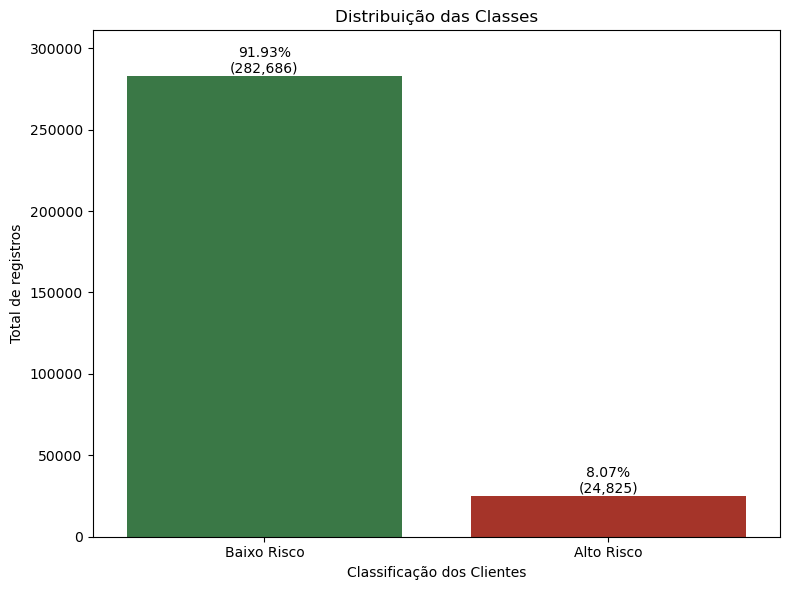

In [4]:
print('- Distribuição da variável Target - \n')

'''
    De acorodo com o dataset:
    'Target variable (1 - client with payment difficulties: 
    he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 
    0 - all other cases)'
'''
# Distribuição da variável target

target=(application_train['TARGET']==1).sum()
target_zero=(application_train['TARGET']==0).sum()
total=len(application_train)
pct = target/total * 100

print(f'Total de linhas de treino: {total}')
print(f'Total de Target 1: {target}')
print(f'Porcentagem da variável Target: {pct:.2f}%')
print(f'Proporção da variável Target: {target_zero/target:.2f}:1\n')

# Criando gráfico de barras
ax = sns.countplot(data=application_train, x='TARGET', hue='TARGET', palette=['#30823F', '#BA2314'], legend=False)

# Alterando os nomes das classes
ax.set_xticks([0, 1])

ax.set_xticklabels(['Baixo Risco', 'Alto Risco'])

# Limite do gráfico em Y
ax.set_ylim(0, application_train['TARGET'].value_counts().max() * 1.1)

# Adicionando porcentagem e contagem sobre cada barra
for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total

    ax.annotate(f'{percent:.2f}%\n({int(height):,})',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=10)

plt.ylabel('Total de registros')
plt.xlabel('Classificação dos Clientes')
plt.title('Distribuição das Classes')

plt.tight_layout()
plt.show()

> O dataset apresenta desbalanceamento das classes: ~ 92% dos clientes classificados com Baixo Risco e ~ 8% dos clientes classificados como Alto Risco, uma proporção de ~ 11:1, o que é normal nesse tipo de situação. A classificação/condição de pagamento dos clientes depende muito do país/região, condição dos clientes e o quanto a própria instituição está disposta a se expor.

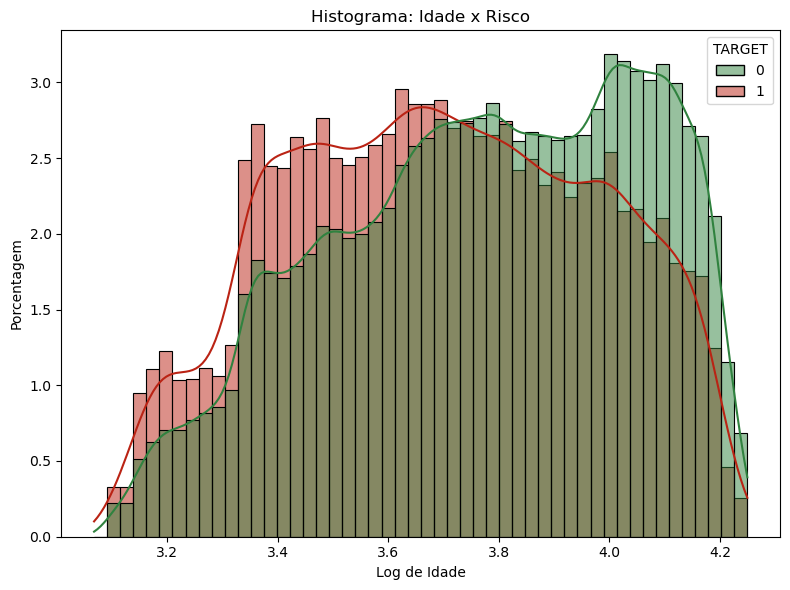


Mediana: Idade (Baixo Risco): 43.46885694729637
Mediana: Idade (Alto Risco): 39.10198494182067


In [5]:
age = -application_train['DAYS_BIRTH'] / 365.25

# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(age)
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log de Idade')
plt.title(f'Histograma: Idade x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = age.groupby(application_train['TARGET']).median()

print(f'\nMediana: Idade (Baixo Risco): {median[0]}')
print(f'Mediana: Idade (Alto Risco): {median[1]}')

> O gráfico nos mostra que pessoas mais jovens tendem a apresentar um risco de crédito maior para a instituição e a mediana confirma essa tendência. Isso também é um comportamento normal, já que pessoas mais jovens possivelmente ainda estão começando uma carreira e não estão bem estabilizadas profissionalmente.

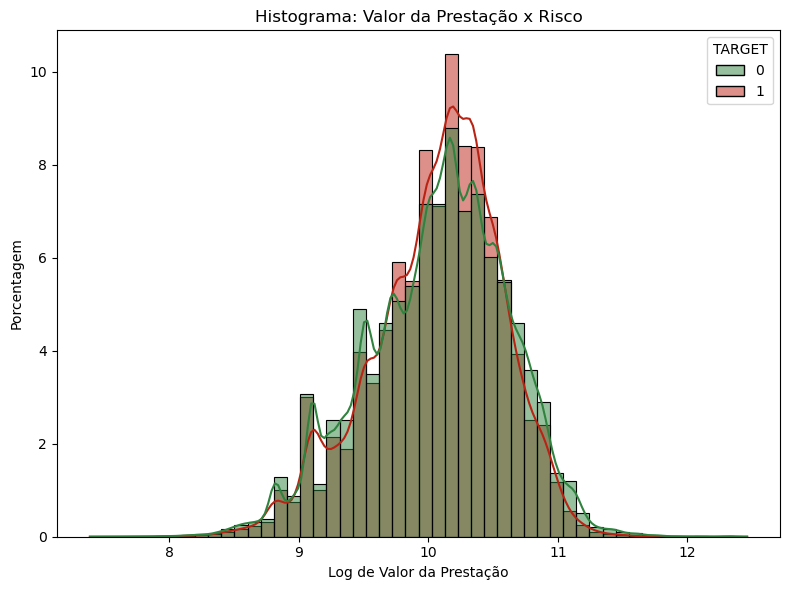


Mediana: Valor da Prestação (Baixo Risco): 24876.0
Mediana: Valor da Prestação (Alto Risco): 25263.0


In [6]:
# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(application_train['AMT_ANNUITY'])
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log de Valor da Prestação')
plt.title(f'Histograma: Valor da Prestação x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = application_train.groupby(application_train['TARGET'])['AMT_ANNUITY'].median()

print(f'\nMediana: Valor da Prestação (Baixo Risco): {median[0]}')
print(f'Mediana: Valor da Prestação (Alto Risco): {median[1]}')

> Analisando o Valor da Prestação x Risco oferecido podemos ver que a distribuição é quase simétrica, com uma pequena tendência para prestações maiores representando maior risco. Aqui o valor da prestação vai pesar quando a capacidade de pagamento do cliente não corresponder com a mesma.

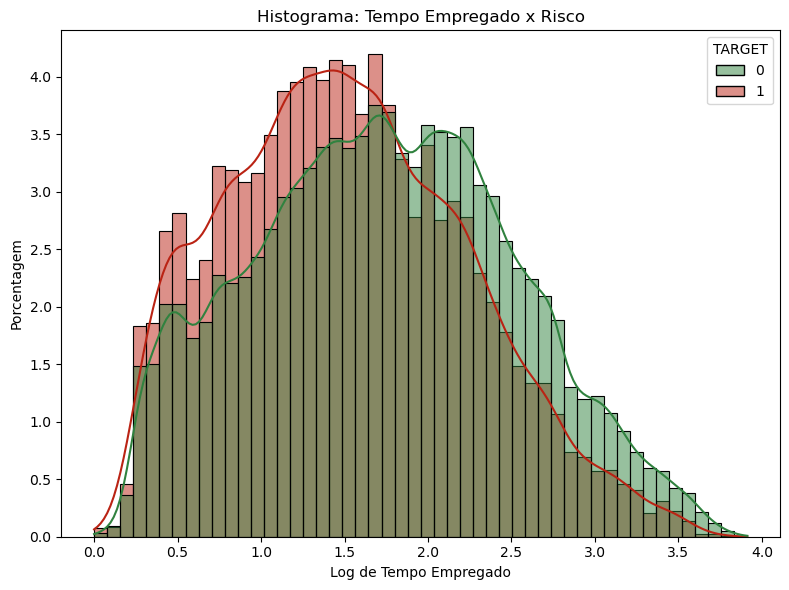


Mediana: Tempo Empregado (Baixo Risco): 4.629705681040384
Mediana: Tempo Empregado (Alto Risco): 3.3675564681724848


In [7]:
years_employed = application_train['DAYS_EMPLOYED'].replace(
    365243, np.nan
)

years_employed = -years_employed / 365.25

# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(years_employed)
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log de Tempo Empregado')
plt.title(f'Histograma: Tempo Empregado x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = years_employed.groupby(application_train['TARGET']).median()

print(f'\nMediana: Tempo Empregado (Baixo Risco): {median[0]}')
print(f'Mediana: Tempo Empregado (Alto Risco): {median[1]}')

> Outra situação esperada, quanto maior o tempo empregado, menor a tendência de risco do cliente. Cliente bem estabilizados profissionalmente apresentam uma tendência de pagamento maior.

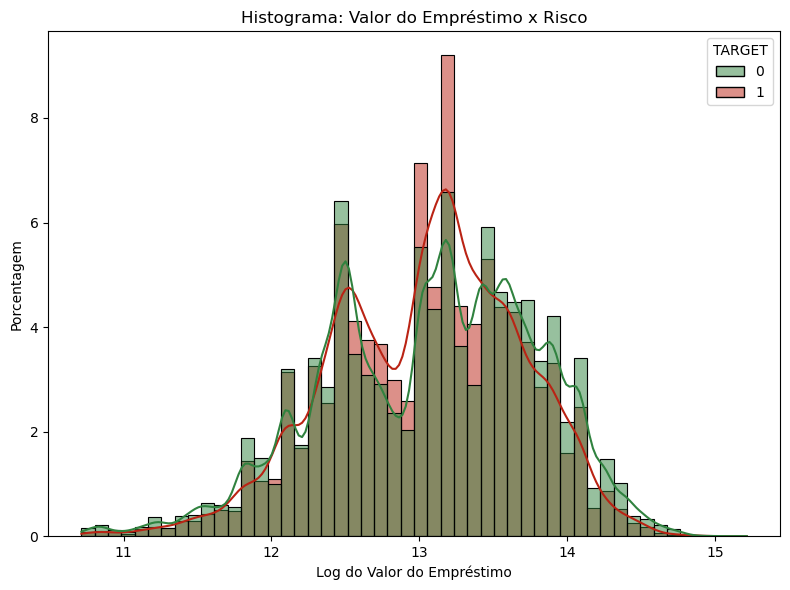


Mediana: Valor do Empréstimo (Baixo Risco): 517788.0
Mediana: Valor do Empréstimo (Alto Risco): 497520.0


In [8]:
# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(application_train['AMT_CREDIT'])
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log do Valor do Empréstimo')
plt.title(f'Histograma: Valor do Empréstimo x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = application_train.groupby(application_train['TARGET'])['AMT_CREDIT'].median()

print(f'\nMediana: Valor do Empréstimo (Baixo Risco): {median[0]}')
print(f'Mediana: Valor do Empréstimo (Alto Risco): {median[1]}')

> Valor do Empréstimo Concedido x Risco, mais uma situação equilibrada, no geral, não necessariamente um empréstimo de valor alto representa um risco maior, isso também está muito ligado com a capacidade de pagamento/endividamento do cliente.

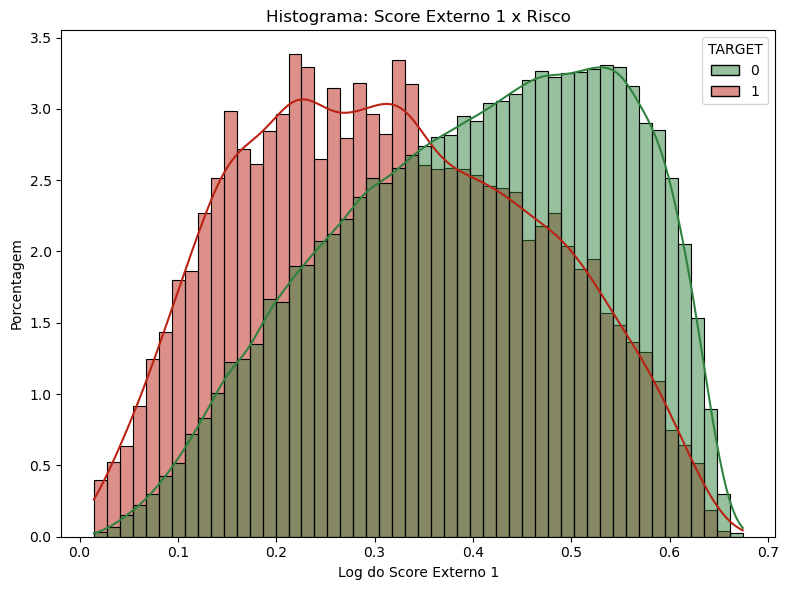


Mediana: Score Externo 1 (Baixo Risco): 0.5174515531911259
Mediana: Score Externo 1 (Alto Risco): 0.36167542779464734


In [9]:
# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(application_train['EXT_SOURCE_1'])
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log do Score Externo 1')
plt.title(f'Histograma: Score Externo 1 x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = application_train.groupby(application_train['TARGET'])['EXT_SOURCE_1'].median()

print(f'\nMediana: Score Externo 1 (Baixo Risco): {median[0]}')
print(f'Mediana: Score Externo 1 (Alto Risco): {median[1]}')

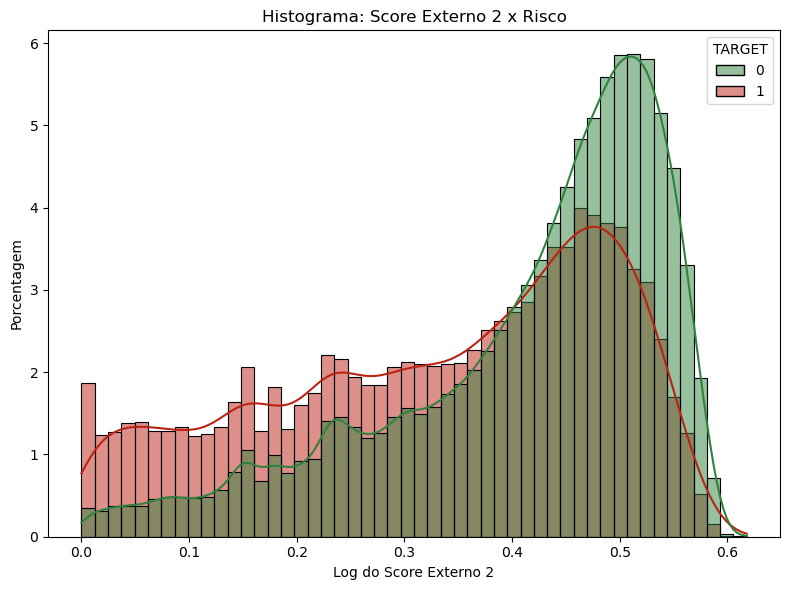


Mediana: Score Externo 2 (Baixo Risco): 0.5739046869026359
Mediana: Score Externo 2 (Alto Risco): 0.4403806303763837


In [10]:
# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(application_train['EXT_SOURCE_2'])
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log do Score Externo 2')
plt.title(f'Histograma: Score Externo 2 x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = application_train.groupby(application_train['TARGET'])['EXT_SOURCE_2'].median()

print(f'\nMediana: Score Externo 2 (Baixo Risco): {median[0]}')
print(f'Mediana: Score Externo 2 (Alto Risco): {median[1]}')

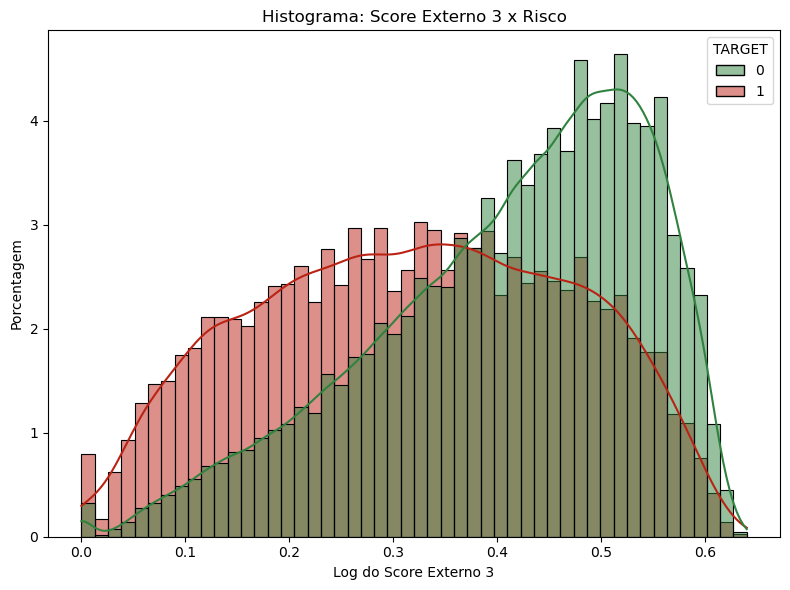


Mediana: Score Externo 3 (Baixo Risco): 0.5460231970049609
Mediana: Score Externo 3 (Alto Risco): 0.3791004853998145


In [11]:
# Utilizar log1p para escalar os dados resolve o problema de dados com valor 0
scaled_data = np.log1p(application_train['EXT_SOURCE_3'])
    
# Plotagem do Gráfico
sns.histplot(application_train, x=scaled_data, hue='TARGET',bins=50, palette=['#30823F', '#BA2314'], stat='percent', kde=True, common_norm=False)
    
plt.ylabel('Porcentagem')
plt.xlabel(f'Log do Score Externo 3')
plt.title(f'Histograma: Score Externo 3 x Risco')

plt.tight_layout()
plt.show()

# Mediana Transações Legítimas x Fraude
median = application_train.groupby(application_train['TARGET'])['EXT_SOURCE_3'].median()

print(f'\nMediana: Score Externo 3 (Baixo Risco): {median[0]}')
print(f'Mediana: Score Externo 3 (Alto Risco): {median[1]}')

> EXT_SOURCE (1,2,3): Representam Scores de pontuação de fontes externas, aqui fica claro, quanto maior o score do cliente, maior a tendência de ele ser um bom pagador e menor o risco que ele apresenta. Esses scores pesam bastante nas decisões dos modelos.

In [12]:
# Valores Nulos
total_missing = application_train.isnull().sum().sum()
print(f'Quantidade de valores nulos no dataset: {total_missing}')

Quantidade de valores nulos no dataset: 9152465


In [13]:
# Razão entre dados nulos x não-nulos

# Lista de colunas
columns_list = list(application_train.columns)

# Lista para guardar os resultados
comparative_results = []

# Tabela comparativa de % de valores missing por coluna e o quanto isso influencia no risco de crédito
for col in columns_list:

    # Porcentagem de valores missing da coluna
    pct_missing = (application_train[col].isnull().sum() * 100 / len(application_train))

    # Agrupar as colunas por influência de valores no risco de crédito
    result = application_train.groupby(application_train[col].isnull())['TARGET'].mean() * 100

    missing_comparative ={
        'coluna': col,
        '% missing': pct_missing.round(4),
        'baixo risco': result.get(False, np.nan),
        'alto risco': result.get(True, np.nan)
    }

    comparative_results.append(missing_comparative)

df_missing_comparative = pd.DataFrame(comparative_results)

# Calcular o valor absoluto da diferença entre: 
# risco de crédito valores nulos x risco de crédito valores não-nulos
df_missing_comparative['diferenca risco'] = abs(df_missing_comparative.iloc[:, 2] - df_missing_comparative.iloc[:, 3])

df_missing_comparative = df_missing_comparative.sort_values(by='% missing', ascending=False)

# Definindo as faixas de porcentagem de valores missing
bins = [-0.01, 0, 20, 40, 60, 80, 100]
labels = ['Nenhum Nulo','0-20%','20-40%','40-60%','60-80%','80-100%']

# Classificando cada coluna em uma faixa
faixas = pd.cut(df_missing_comparative['% missing'], bins=bins, labels=labels)

df_missing_comparative['faixas missing'] = faixas.values

df_missing_comparative

,coluna,% missing,baixo risco,alto risco,diferenca risco,faixas missing
76,COMMONAREA_MEDI,69.8723,6.910174,8.574221,1.664047,60-80%
48,COMMONAREA_AVG,69.8723,6.910174,8.574221,1.664047,60-80%
62,COMMONAREA_MODE,69.8723,6.910174,8.574221,1.664047,60-80%
70,NONLIVINGAPARTMENTS_MODE,69.4330,6.912987,8.583512,1.670526,60-80%
56,NONLIVINGAPARTMENTS_AVG,69.4330,6.912987,8.583512,1.670526,60-80%
...,...,...,...,...,...,...
15,NAME_HOUSING_TYPE,0.0000,8.072882,NaN,NaN,Nenhum Nulo
14,NAME_FAMILY_STATUS,0.0000,8.072882,NaN,NaN,Nenhum Nulo
13,NAME_EDUCATION_TYPE,0.0000,8.072882,NaN,NaN,Nenhum Nulo
12,NAME_INCOME_TYPE,0.0000,8.072882,NaN,NaN,Nenhum Nulo


In [14]:
# Quantidade de colunas em cada faixa de valores missing
df_missing_comparative['faixas missing'].value_counts().sort_index()

faixas missing
Nenhum Nulo    55
0-20%          17
20-40%          1
40-60%         32
60-80%         17
80-100%         0
Name: count, dtype: int64

## Feature Engineering

#### Funções

In [15]:
# Função de Agregação Genérica
def generic_agg(df, group_col, exclude_cols=None, cat_max_unique=10, num_stats=('sum', 'count', 'max', 'min'),
                high_card_top_n=10, high_card_other_label='OUTROS'):
    '''
    -> Agrega df por group_col
    -> Colunas numéricas: sum + count (não utiliza mean)
    -> Colunas Categóricas de baixa cardinalidade: one-hot + sum (contagem por categoria)
    -> Colunas Categóricas de alta cardinalidade: reduz para as high_card_top_n categorias
       mais frequentes, agrupando o resto em high_card_other_label, e então one-hot + sum
    '''
    # Colunas a serem ignoradas
    exclude_cols = set(exclude_cols or []) | {group_col}

    # Separa as colunas em numéricas e categóricas
    num_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude_cols]
    cat_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns if c not in exclude_cols]

    # Agrega as colunas numéricas
    num_agg = df.groupby(group_col)[num_cols].agg(list(num_stats))
    num_agg.columns = [f'{col}_{stat}'.upper() for col, stat in num_agg.columns]

    # Separa as cardinalidade das colunas categóricas
    low_card_cats = [c for c in cat_cols if df[c].nunique() <= cat_max_unique]
    high_card_cats = [c for c in cat_cols if c not in low_card_cats]

    # Cópia das colunas categóricas que vão virar dummies
    cat_df = df[[group_col] + low_card_cats + high_card_cats].copy()

    # Reduz cardinalidade das colunas de alta cardinalidade
    for col in high_card_cats:
        top = cat_df[col].value_counts().nlargest(high_card_top_n).index
        cat_df[col] = cat_df[col].where(cat_df[col].isin(top), high_card_other_label)

    all_cat_cols = low_card_cats + high_card_cats
    if all_cat_cols:
        dummies = pd.get_dummies(cat_df[[group_col] + all_cat_cols], columns=all_cat_cols)
        cat_agg = dummies.groupby(group_col).sum()
        result = num_agg.join(cat_agg, how='left')
    else:
        result = num_agg

    return result.reset_index()


# Função de Agregação de Múltiplas Camadas
def rollup_agg(df, group_col):
    """
    Reagrega uma tabela que já passou por generic_agg (ou por rollup_agg antes)
    _SUM e _COUNT sempre se somam; 
    _MAX sempre repete max; 
    _MIN sempre repete min.
    Colunas de one-hot/contagem categórica (sem sufixo _SUM/_MAX/_MIN/_COUNT) também se somam
    """
    # Dicionário de Agregação
    agg_dict = {}

    # Percorre as colunas e preenche o dicionário
    for col in df.columns:
        if col == group_col:
            continue
        elif col.endswith('_MAX'):
            agg_dict[col] = 'max'
        elif col.endswith('_MIN'):
            agg_dict[col] = 'min'
        else:
            agg_dict[col] = 'sum'

    # Retorna o dataframe agregado
    return df.groupby(group_col).agg(agg_dict).reset_index()


# Função para adicionar sufixo nas tabelas
def add_suffix(df, suffix, exclude_cols=None):
    
    if exclude_cols is None:
        exclude_cols = ['SK_ID_PREV', 'SK_ID_CURR']
    
    return df.rename(
        columns={
            col: f'{col}{suffix}'
            for col in df.columns
            if col not in exclude_cols
        }
    )

#### Agregações

In [16]:
# 1 - Agregar o histórico de créditos em bureau_balance e unir com a tabela bureau

'''
 De acordo com a descrição da feature STATUS:
 C -> Crédito Encerrado
 X -> Status Desconhecido
 0-5 -> 0 significa que o crédito foi pago normalmente, enquanto 1-5 representa atraso, sendo 1 0-30 dias e 5 120+ dias
 Por isso é interessante fazer uma análise numérica dessa coluna
'''
# Cria uma coluna contendo os status numéricos
bureau_balance['STATUS_NUM'] = pd.to_numeric(
    bureau_balance['STATUS'],
    errors = 'coerce'
)

# Agregação SK_ID_BUREAU -> STATUS_NUM
bureau_balance_generic_agg = generic_agg(
    bureau_balance,
    group_col='SK_ID_BUREAU',
    exclude_cols=['STATUS', 'MONTHS_BALANCE']
)

# Identifica o status do mês mais recente (C, X, 0-5)
# Cria uma coluna categóricas para o status do crédito - C = Encerrado, X = Desconhecido e 0-5 = Aberto
bureau_status = bureau_balance.loc[
    bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].idxmax()
].copy()

bureau_status['CREDIT_STATUS'] = np.select(
    [bureau_status['STATUS'] == 'C',
     bureau_status['STATUS'] == 'X',
     bureau_status['STATUS'].isin(['0', '1', '2', '3', '4', '5'])],
    
    ['Encerrado', 'Desconhecido', 'Aberto'],
    default='Desconhecido'
)

bureau_status = bureau_status[['SK_ID_BUREAU', 'CREDIT_STATUS']]

# Merge das tabelas
bureau_balance_agg = bureau_balance_generic_agg.merge(
    bureau_status,
    on='SK_ID_BUREAU',
    how='left'
)

# Cria os dummies para a coluna categórica (One Hot Encoding)
bureau_balance_agg = pd.get_dummies(bureau_balance_agg, columns=['CREDIT_STATUS'])

# 2 - Unir bureau_balance_agg em bureau por SK_ID_BUREAU e agregar SK_ID_CURR -> SK_ID_BUREAU

'''
    Cada cliente representa um SK_ID_CURR
    Cada SK_ID_CURR pode ter múltiplos SK_ID_BUREAU
'''

# Mapeamento das chaves SK_ID_CURR e SK_ID_BUREAU
id_map = bureau[['SK_ID_BUREAU', 'SK_ID_CURR']]

# Anexa SK_ID_CURR em bureau_balance_agg, sem tocar nas colunas originais de bureau
bureau_balance_agg = bureau_balance_agg.merge(id_map, on='SK_ID_BUREAU', how='left')

# Reagrega bureau_balance por SK_ID_CURR -> SK_ID_BUREAU
bureau_balance_rollup = rollup_agg(
    bureau_balance_agg.drop(columns=['SK_ID_BUREAU']),
    group_col='SK_ID_CURR'
)

# Coluna auxiliar que indica quando a instituição teve que vender/assumir o prejuízo da dívida
bureau['CREDIT_LOSS'] = bureau['CREDIT_ACTIVE'].isin(['Sold', 'Bad debt']).astype(int)

# Agrega bureau por SK_ID_CURR -> SK_ID_BUREAU
bureau_generic_agg = generic_agg(bureau, group_col='SK_ID_CURR', exclude_cols=['SK_ID_BUREAU'])

'''
    Merge das agregações
    Dados vindos de bureau_balance reagreagados por SK_ID_CURR + Dados da tabela bureau
'''
bureau_agg = bureau_generic_agg.merge(
    bureau_balance_rollup, 
    on='SK_ID_CURR', 
    how='left'
)

# Realiza a média ponderada das colunas cumulativas
for col in [c for c in bureau_agg.columns if c.endswith('_SUM')]:
    base = col[:-4]
    count_col = f'{base}_COUNT'
    if count_col in bureau_agg.columns:
        bureau_agg[f'{base}_WEIGHTED_MEAN'] = bureau_agg[col] / bureau_agg[count_col]

# 3 - Agregar POS_CASH_balance por SK_ID_PREV

# Agrega as colunas de POS_CASH_balance por SK_ID_PREV
cash_generic_agg=generic_agg(
    cash_balance,
    group_col='SK_ID_PREV',
    exclude_cols=['SK_ID_CURR', 'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS']
)

# Separação por status do contrato
active_status = ['Active', 'Signed', 'Approved']
finished_status = ['Completed', 'Returned to the store', 'Canceled']
debt_status = ['Demand', 'Amortized debt']

# Identifica o status do contrato através do último mês registrado
contract_status = cash_balance.loc[
    cash_balance.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()
].copy()

contract_status['CONTRACT_STATUS'] = np.select(
    [
        contract_status['NAME_CONTRACT_STATUS'].isin(active_status),
        contract_status['NAME_CONTRACT_STATUS'].isin(finished_status),
        contract_status['NAME_CONTRACT_STATUS'].isin(debt_status)
    ],
    ['Ativo', 'Encerrado', 'Prejuízo'],
    default='Desconhecido'
)

contract_status = contract_status[['SK_ID_PREV', 'SK_ID_CURR','CONTRACT_STATUS']]

# Merge das tabelas
cash_agg = cash_generic_agg.merge(
    contract_status,
    on='SK_ID_PREV',
    how='left'
)

# Cria os dummies para a coluna categórica (One Hot Encoding)
cash_agg = pd.get_dummies(cash_agg, columns=['CONTRACT_STATUS'])

# 4 - Agregar credit_card_balance por SK_ID_PREV

# Agregação genérica de credit_card_balance
card_generic_agg=generic_agg(
    card_balance,
    group_col='SK_ID_PREV',
    exclude_cols=['SK_ID_CURR', 'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS', 'CNT_INSTALMENT_MATURE_CUM']
)

# Agregação da coluna cumulativa (queremos apenas o valor máximo)
cumulative_agg = card_balance.groupby('SK_ID_PREV').agg(
    MAX_PARCEL_PAID=('CNT_INSTALMENT_MATURE_CUM', 'max')
)

# Separação por status do contrato
active_status = ['Active', 'Signed', 'Approved', 'Sent proposal']
finished_status = ['Completed', 'Refused']
debt_status = ['Demand']

# Identifica o status do contrato através do último mês registrado
contract_status = card_balance.loc[
    card_balance.groupby('SK_ID_PREV')['MONTHS_BALANCE'].idxmax()
].copy()

contract_status['CONTRACT_STATUS'] = np.select(
    [
        contract_status['NAME_CONTRACT_STATUS'].isin(active_status),
        contract_status['NAME_CONTRACT_STATUS'].isin(finished_status),
        contract_status['NAME_CONTRACT_STATUS'].isin(debt_status)
    ],
    ['Ativo', 'Encerrado', 'Prejuízo'],
    default='Desconhecido'
)

contract_status = contract_status[['SK_ID_PREV', 'SK_ID_CURR','CONTRACT_STATUS']]

# Merge das tabelas
card_agg = card_generic_agg.merge(
    contract_status,
    on='SK_ID_PREV',
    how='left'
)

card_agg = card_agg.merge(
    cumulative_agg,
    on='SK_ID_PREV',
    how='left'
)

# Cria os dummies para a coluna categórica (One Hot Encoding)
card_agg = pd.get_dummies(card_agg, columns=['CONTRACT_STATUS'])

# 5 - Agregar installments_payments por SK_ID_PREV
'''
 Diferença entre o vencimento da parcela e o dia do pagamento da parcela
 Valores positivos indicam pagamentos atrasados
 Valores negativos indicam pagamentos adiantados
'''
installments_payments['PAYMENT_DAYS'] = installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']

'''
 Identificar as parcelas vencidas e nunca pagas
 Condição: não tem valor de pagamento registrado AMT_PAYMENT nulo
 E o vencimento já passou DAYS_INSTALMENT < 0, ou seja, já venceu antes da solicitação atual
'''
unpaid_mask = (
    installments_payments['AMT_PAYMENT'].isna() &
    (installments_payments['DAYS_INSTALMENT'] < 0)
)
installments_payments['UNPAID_INSTALLMENT'] = unpaid_mask.astype(int)

# Agregação da coluna N_VERSIONS (queremos saber a qtd de valores únicos)
unique_agg = installments_payments.groupby('SK_ID_PREV').agg(
    N_VERSIONS=('NUM_INSTALMENT_VERSION', 'nunique')
)

# Agregação genérica de installments_payments
inst_generic_agg=generic_agg(
    installments_payments,
    group_col='SK_ID_PREV',
    exclude_cols=['SK_ID_CURR', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT', 'NUM_INSTALMENT_VERSION']
)

# Busca o SK_ID_CURR de installment_payments
id_map = installments_payments[['SK_ID_PREV', 'SK_ID_CURR']]

# Merge das tabelas
inst_agg = inst_generic_agg.merge(
    unique_agg,
    on='SK_ID_PREV',
    how='left'
)

inst_agg = inst_agg.merge(
    id_map,
    on='SK_ID_PREV',
    how='left'
)

# 6 - Reagregar as tabelas inst_agg, cash_agg e card_agg

# Reagrega as tabelas por SK_ID_CURR -> SK_ID_PREV
cash_rollup = rollup_agg(
    cash_agg.drop(columns=['SK_ID_PREV']), 
    group_col='SK_ID_CURR'
)

card_rollup = rollup_agg(
    card_agg.drop(columns=['SK_ID_PREV']), 
    group_col='SK_ID_CURR'
)

inst_rollup = rollup_agg(
    inst_agg.drop(columns=['SK_ID_PREV']), 
    group_col='SK_ID_CURR'
)

# Realiza a média ponderada das colunas cumulativas
for df_rollup in [cash_rollup, card_rollup, inst_rollup]:
    for col in [c for c in df_rollup.columns if c.endswith('_SUM')]:
        base = col[:-4]
        count_col = f'{base}_COUNT'
        if count_col in df_rollup.columns:
            df_rollup[f'{base}_WEIGHTED_MEAN'] = df_rollup[col] / df_rollup[count_col]

# 7 - Agregar previous_application

# Agregação genérica de previous_application
prev_generic_agg = generic_agg(
    previous_application,
    group_col='SK_ID_CURR',
    exclude_cols=['SK_ID_PREV', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', ]
)

# Realiza a média ponderada das colunas cumulativas
for col in [c for c in prev_generic_agg.columns if c.endswith('_SUM')]:
    base = col[:-4]
    count_col = f'{base}_COUNT'
    if count_col in prev_generic_agg.columns:
        prev_generic_agg[f'{base}_WEIGHTED_MEAN'] = prev_generic_agg[col] / prev_generic_agg[count_col]

# 8 - Adicionar o sufixo corresponde a cada tabela

bureau_agg = add_suffix(
    bureau_agg,
    '_BUREAU',
    exclude_cols=['SK_ID_CURR']
)

cash_rollup = add_suffix(cash_rollup, '_CASH')
card_rollup = add_suffix(card_rollup, '_CARD')
inst_rollup = add_suffix(inst_rollup, '_INST')
prev_agg = add_suffix(prev_generic_agg, '_PREV')

# 9 - Merge de previous_application agregado + as três tabelas (inst_agg, cash_agg e card_agg)

prev_agg = (
    prev_agg
    .merge(cash_rollup, on='SK_ID_CURR', how='left')
    .merge(card_rollup, on='SK_ID_CURR', how='left')
    .merge(inst_rollup, on='SK_ID_CURR', how='left')
)

# 10 - Merge de prev_agg e bureau_agg

final_agg = prev_agg.merge(bureau_agg, on='SK_ID_CURR', how='outer')

# 11 - Enriquecer application_train com base nas features mais importantes

# Comprometimento financeiro
application_train['CREDIT_INCOME_RATIO'] = application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']
application_train['ANNUITY_INCOME_RATIO'] = application_train['AMT_ANNUITY'] / application_train['AMT_INCOME_TOTAL']
application_train['CREDIT_ANNUITY_RATIO'] = application_train['AMT_CREDIT'] / application_train['AMT_ANNUITY']

# Idade por tempo de emprego
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace(
    365243, np.nan)

application_train['AGE_EMPLOYED_RATIO'] = application_train['DAYS_BIRTH'] / application_train['DAYS_EMPLOYED']

# Removendo valores infinitos
ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO', 'AGE_EMPLOYED_RATIO']

application_train[ratio_cols] = application_train[ratio_cols].replace([np.inf, -np.inf], np.nan)

# Combinações dos EXT_SOURCE, os scores externos, as features com maior importância na previsão
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
application_train['EXT_SOURCE_MEAN'] = application_train[ext_source_cols].mean(axis=1)
application_train['EXT_SOURCE_STD'] = application_train[ext_source_cols].std(axis=1)
application_train['EXT_SOURCE_PROD'] = application_train[ext_source_cols].prod(axis=1)

# 12 - Unir todas as tabelas agregadas (final_agg) com applicaiton_train via SK_ID_CURR

df_train = application_train.merge(final_agg, on='SK_ID_CURR', how='left')

# 13 - Tratamento dos valores NaN

# Separa as colunas que vieram de final_agg
engineered_cols = [c for c in df_train.columns if c.endswith(('_BUREAU', '_PREV', '_CASH', '_CARD', '_INST'))]

# Cria uma flag identificando se o cliente possui histórico de bureau ou previous application
df_train['HAS_BUREAU_HISTORY'] = df_train[[c for c in df_train.columns if c.endswith('_BUREAU')]].notna().any(axis=1).astype(int)
df_train['HAS_PREV_HISTORY'] = df_train[[c for c in df_train.columns if c.endswith('_PREV')]].notna().any(axis=1).astype(int)

# Trata os valores nulos vindos de soma/contagem/one-hot
sum_count_onehot_cols = [c for c in engineered_cols if not c.endswith(('_MAX', '_MIN', '_WEIGHTED_MEAN'))]
df_train[sum_count_onehot_cols] = df_train[sum_count_onehot_cols].fillna(0)

## Pré-processamento

In [17]:
# Features e target
X = df_train.drop('TARGET', axis=1)
y = df_train['TARGET']

# Separação dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=0, stratify=y)

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}\n")

# Tratando valores missing
columns_list = list(X_train.columns)

cols_notna = []
cols_under20 = []
cols_under60 = []
cols_over60 = []

for col in columns_list:

    pct_missing = (X_train[col].isnull().sum() * 100 / len(X_train))

    if pct_missing == 0:
        cols_notna.append(col)
    elif pct_missing < 20:
       cols_under20.append(col)
    elif pct_missing < 60:
        cols_under60.append(col)
    else:
        cols_over60.append(col)
    
set_notna = set(cols_notna)
set_under20 = set(cols_under20)
set_under60 = set(cols_under60)
set_over60 = set(cols_over60)

num_set = set(list(X.select_dtypes(include=np.number)))
cat_set = set(list(X.select_dtypes(exclude=np.number)))

sets = {
    'num_notna': set_notna & num_set,
    'cat_notna': set_notna & cat_set,
    'num_under20': set_under20 & num_set,
    'cat_under20': set_under20 & cat_set,
    'num_under60': set_under60 & num_set,
    'cat_under60': set_under60 & cat_set,
    'over60': set_over60
}

# Pré-processamento
# Scaler, Imputer e Encoding das variáveis
preprocessor = ColumnTransformer([
    ('num_notna', Pipeline([
        ('scaler', StandardScaler())
    ]), list(sets['num_notna'])),

    ('cat_notna', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ]), list(sets['cat_notna'])),

    ('num_under20', Pipeline([
        ('simpleimp', SimpleImputer(missing_values=np.nan, strategy='median')),
        ('scaler', StandardScaler())
    ]), list(sets['num_under20'])),

    ('cat_under20', Pipeline([
        ('simpleimp', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Não Informado')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ]), list(sets['cat_under20'])),

    ('num_under60', Pipeline([
        ('simpleimp', SimpleImputer(missing_values=np.nan, strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())
    ]), list(sets['num_under60'])),

    ('cat_under60', Pipeline([
        ('simpleimp', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Não Informado', add_indicator=True)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ]), list(sets['cat_under60'])),

    ('over60', Pipeline([
        ('missingimp', MissingIndicator(missing_values=np.nan))
    ]), list(sets['over60']))
])

# Transforma o resultado do pré-processamento em um DataFrame
preprocessor.set_output(transform='pandas')

# Aplica o pré-processamento + treino no dados de treino e só o pré-processamento no dados de teste
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Limpa os nomes das colunas
def clean_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in df.columns]
    return df

X_train_transformed = clean_columns(X_train_transformed)
X_test_transformed = clean_columns(X_test_transformed)

# Conferindo se as colunas estão na ordem correta e com os mesmos nomes nos dois dataframes
col_order = (X_train_transformed.columns == X_test_transformed.columns).all()
if col_order == True:
    print('DataFrames corretamente alinhados!')
else:
    print('DataFrames não estão alinhados!')

Tamanho do conjunto de treino: 230633
Tamanho do conjunto de teste: 76878

DataFrames corretamente alinhados!


### Feature Selection

In [18]:
# Identificando as features mais importantes do dataset
selector_model = lgb.LGBMClassifier(n_estimators=200, class_weight='balanced', random_state=0, verbose=-1)
selector_model.fit(X_train_transformed, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'Importance': selector_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

# Corta as colunas sem relação com o Target através da meadiana
selector = SelectFromModel(selector_model, prefit=True, threshold='median')
X_train_selected = X_train_transformed.loc[:, selector.get_support()]
X_test_selected = X_test_transformed.loc[:, selector.get_support()]

print(f'\nColunas antes: {X_train_transformed.shape[1]} -> depois: {X_train_selected.shape[1]}')

                                               Feature  Importance
563                  num_under20__CREDIT_ANNUITY_RATIO         197
565                       num_under20__EXT_SOURCE_MEAN         151
137                              num_notna__DAYS_BIRTH         132
574                           num_under20__AMT_ANNUITY         114
146                   num_notna__PAYMENT_DAYS_MAX_INST          88
215                         num_notna__EXT_SOURCE_PROD          86
573                          num_under20__EXT_SOURCE_3          81
581                    num_under20__AGE_EMPLOYED_RATIO          76
376                  num_notna__DAYS_CREDIT_MAX_BUREAU          74
242                         num_notna__DAYS_ID_PUBLISH          70
566                          num_under20__EXT_SOURCE_2          69
295  num_notna__CNT_INSTALMENT_FUTURE_WEIGHTED_MEAN...          68
70                               num_notna__AMT_CREDIT          65
578                       num_under20__AMT_GOODS_PRICE        

In [19]:
# Função para análise de autocorrelação
def correlated_groups(columns, threshold):

    # Calcula a correlação para as colunas
    cols_corr = columns.corr(method='spearman')

    # Cria um filtro removendo a diagonal principal e o triângulo inferior
    mask = np.triu(np.ones_like(cols_corr, dtype=bool), k=1)
    corr_filtered = cols_corr.where(mask)

    # Empilha o dataframe filtrado
    corr_stacked = corr_filtered.stack()
    # Filtra pelas correlações mais fortes
    strong_corr = corr_stacked[corr_stacked > threshold]
    # Transforma o resultado em uma lista
    corr_list = list(strong_corr.index)

    # Cria um gráfico vazio e conecta as correlações
    G = nx.Graph()
    edges = G.add_edges_from(corr_list)
    correlations = list(nx.connected_components(G))

    return correlations

In [20]:
# Feature importances
importances = pd.Series(selector_model.feature_importances_, index=X_train_transformed.columns)

# Analisar a autocorrelação entre as features
corr_matrix = X_train_selected.corr().abs()

# Cria grupos autocorrelacionados com um limiar de 90% de correlação
groups = correlated_groups(corr_matrix, threshold=0.9)

# Dentro de cada grupo correlacionado, mantém só a coluna de maior importância
importances_selected = importances[X_train_selected.columns]

cols_to_drop = []
for group in groups:
    group_importances = importances_selected[list(group)]
    keep = group_importances.idxmax()
    cols_to_drop.extend([c for c in group if c != keep])

X_train_final = X_train_selected.drop(columns=cols_to_drop)
X_test_final = X_test_selected.drop(columns=cols_to_drop)

### Preparação para Redes Neurais

In [21]:
# Criando o conjunto de validaçãa em cima do conjunto de treino
# O conjunto de teste continua isolado
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_train_final, y_train,train_size=0.85,random_state=0,stratify=y_train)

print(f'Treino: {X_train_nn.shape[0]}')
print(f'Validação: {X_val_nn.shape[0]}')
print(f'Teste: {X_test_final.shape[0]}')

# Transformar os dados para o padrão do Keras - arrays numpy
X_train_arr = np.asarray(X_train_nn).astype('float32')
X_val_arr = np.asarray(X_val_nn).astype('float32')
X_test_arr = np.asarray(X_test_final).astype('float32')

y_train_arr = np.asarray(y_train_nn).astype('float32')
y_val_arr = np.asarray(y_val_nn).astype('float32')
y_test_arr = np.asarray(y_test).astype('float32')

# Determinar os pesos das classes
'''
    Um erro da classe 1 (Alto Risco) deve pesar muito mais do que
    um erro da classe 0 (Baixo Risco), a fim de compensar o desbalanceamento
    das classes.
'''
weights = compute_class_weight('balanced', classes=np.unique(y_train_nn), y=y_train_nn)
class_weight = dict(zip(np.unique(y_train_nn).astype(int), weights))

Treino: 196038
Validação: 34595
Teste: 76878


## Modelo Rede Neural

In [22]:
# Montando a estrutura do modelo
model = keras.Sequential([
    layers.Input(shape=(X_train_arr.shape[1],)),  # 176 features de entrada

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')  # saída: probabilidade entre 0 e 1
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,873 (62.00 KB)

 Trainable params: 15,681 (61.25 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
# Compilando o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='roc_auc', curve='ROC')]
)

# Monitora o aprendizado do modelo
early_stop = EarlyStopping(
    monitor='val_roc_auc',
    mode='max',
    patience=7,
    restore_best_weights=True
)

# Monitora a taxa de aprendizado
reduce_lr = ReduceLROnPlateau(
    monitor='val_roc_auc', 
    mode='max', 
    factor=0.5, 
    patience=3
)

# Treino e validação do modelo
history = model.fit(
    X_train_arr, y_train_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.6808 - roc_auc: 0.6562 - val_loss: 0.6094 - val_roc_auc: 0.7403
Epoch 2/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6134 - roc_auc: 0.7300 - val_loss: 0.6175 - val_roc_auc: 0.7511
Epoch 3/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6024 - roc_auc: 0.7422 - val_loss: 0.6049 - val_roc_auc: 0.7536
Epoch 4/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5945 - roc_auc: 0.7512 - val_loss: 0.6078 - val_roc_auc: 0.7555
Epoch 5/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5906 - roc_auc: 0.7549 - val_loss: 0.5978 - val_roc_auc: 0.7565
Epoch 6/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5878 - roc_auc: 0.7583 - val_loss: 0.5957 - val_roc_auc: 0.7571
Epoch 7/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5861 - roc_auc: 0.7596 - val_loss: 0.5943 - val_roc_auc: 0.7587
Epoch 8/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5848 - roc_auc: 0.7616 - val_loss: 0.5893 - val

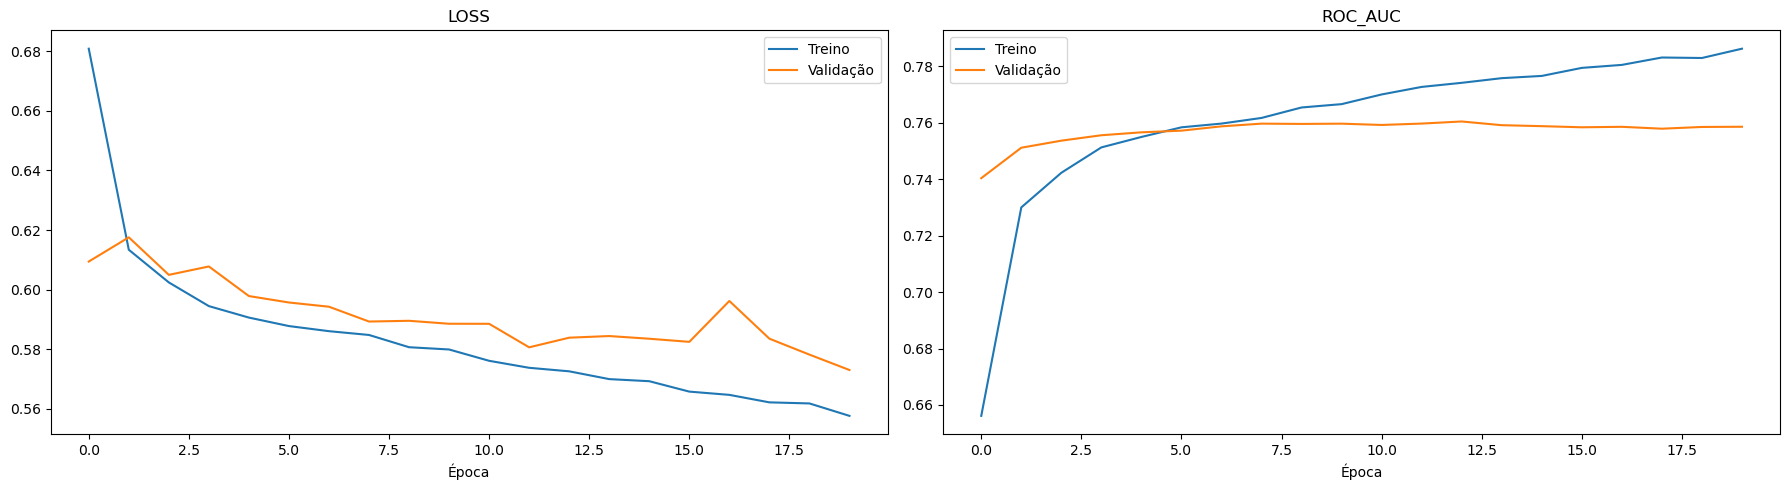

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

metrics = ['loss', 'roc_auc']

for ax, metric in zip(axes, metrics):
    ax.plot(history.history[metric], label='Treino')
    ax.plot(history.history[f'val_{metric}'], label='Validação')
    ax.set_title(metric.upper())
    ax.set_xlabel('Época')
    ax.legend()

plt.tight_layout()
plt.show()

NN: 64 - 32 - 16 = Epoch 18/100 loss: 0.5537 - pr_auc: 0.2527 - roc_auc: 0.7898 - val_loss: 0.5559 - val_pr_auc: 0.2429 - val_roc_auc: 0.7629

NN: 128 - 64 - 32 = Epoch 10/100 loss: 0.5576 - pr_auc: 0.2538 - roc_auc: 0.7863 - val_loss: 0.5424 - val_pr_auc: 0.2422 - val_roc_auc: 0.7618

NN: 64 - 32 - 16 (0.35/0.35/0.25) = Epoch 13/100 loss: 0.5711 - pr_auc: 0.2370 - roc_auc: 0.7748 - val_loss: 0.5645 - val_pr_auc: 0.2402 - val_roc_auc: 0.7634

NN: 64 - 32 - 16 (0.4/0.4/0.3) = Epoch 21/100 loss: 0.5639 - pr_auc: 0.2408 - roc_auc: 0.7820 - val_loss: 0.5651 - val_pr_auc: 0.2411 - val_roc_auc: 0.7652

NN: 64 - 32 - 16 (0.4/0.4/0.3) l2=(0.001) = Epoch 41/100 loss: 0.5948 - pr_auc: 0.2333 - roc_auc: 0.7677 - val_loss: 0.5999 - val_pr_auc: 0.2388 - val_roc_auc: 0.7623

NN: 64 - 32 - 16 (0.4/0.4/0.3) l2=(0.005) = Epoch 29/100 loss: 0.6094 - pr_auc: 0.2243 - roc_auc: 0.7533 - val_loss: 0.5929 - val_pr_auc: 0.2274 - val_roc_auc: 0.7559

NN: 64 - 32 - 16 (0.4/0.4/0.3) reduce_lr = Epoch 16/100 loss: 0.5712 - pr_auc: 0.2370 - roc_auc: 0.7746 - val_loss: 0.5576 - val_pr_auc: 0.2413 - val_roc_auc: 0.7642 - learning_rate: 0.0010

NN: 64 - 32 - 16 (0.4/0.4/0.3) batch(128) = Epoch 1/100 loss: 0.5746 - pr_auc: 0.2316 - roc_auc: 0.7724 - val_loss: 0.5866 - val_pr_auc: 0.2416 - val_roc_auc: 0.7640 - learning_rate: 0.0010

NN: 64 - 32 - 16 (0.4/0.4/0.3) batch(512) = Epoch 1/100 loss: 0.5688 - pr_auc: 0.2412 - roc_auc: 0.7775 - val_loss: 0.5648 - val_pr_auc: 0.2403 - val_roc_auc: 0.7635 - learning_rate: 0.0010

NN: 64 - 32 - 16 (0.4/0.4/0.3) reduce_lr = Epoch 20/100 loss: 0.5643 - pr_auc: 0.2446 - roc_auc: 0.7821 - val_loss: 0.5678 - val_pr_auc: 0.2424 - val_roc_auc: 0.7632 - learning_rate: 5.0000e-04

## Avaliação final do modelo

2403/2403 ━━━━━━━━━━━━━━━━━━━━ 1s 495us/step

ROC-AUC final (teste): 0.7687

Matriz de Confusão:
[[47628 23044]
 [ 1688  4518]] 



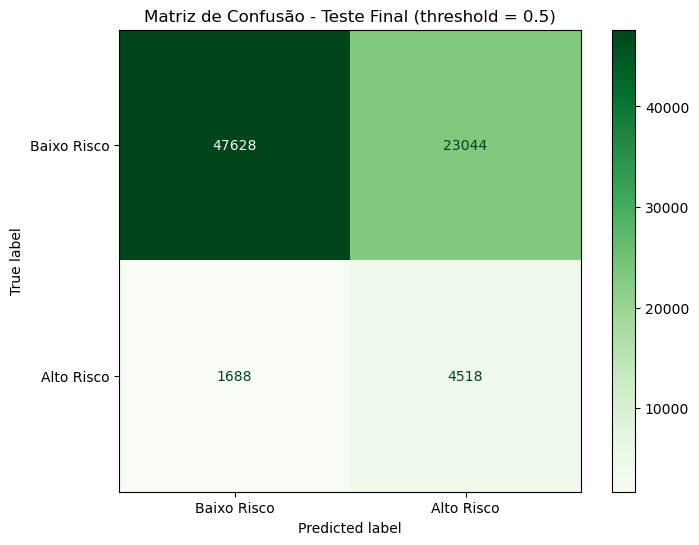

TN (Baixo Risco classificados corretamente): 47628
FP (Baixo Risco classificados como Alto Risco): 23044
FN (Alto Risco classificados como Baixo Risco): 1688
TP (Alto Risco classificados corretamente): 4518

Classification Report:
              precision    recall  f1-score   support

 Baixo Risco     0.9658    0.6739    0.7939     70672
  Alto Risco     0.1639    0.7280    0.2676      6206

    accuracy                         0.6783     76878
   macro avg     0.5648    0.7010    0.5307     76878
weighted avg     0.9010    0.6783    0.7514     76878



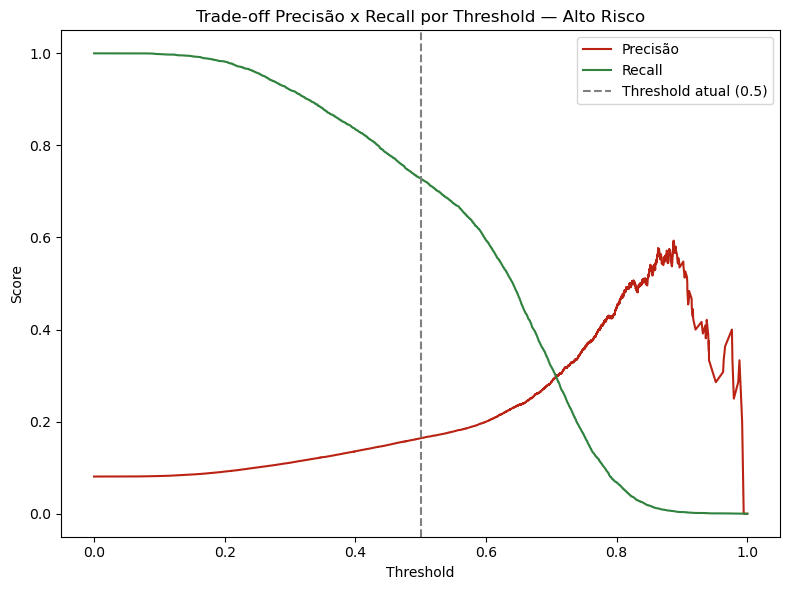

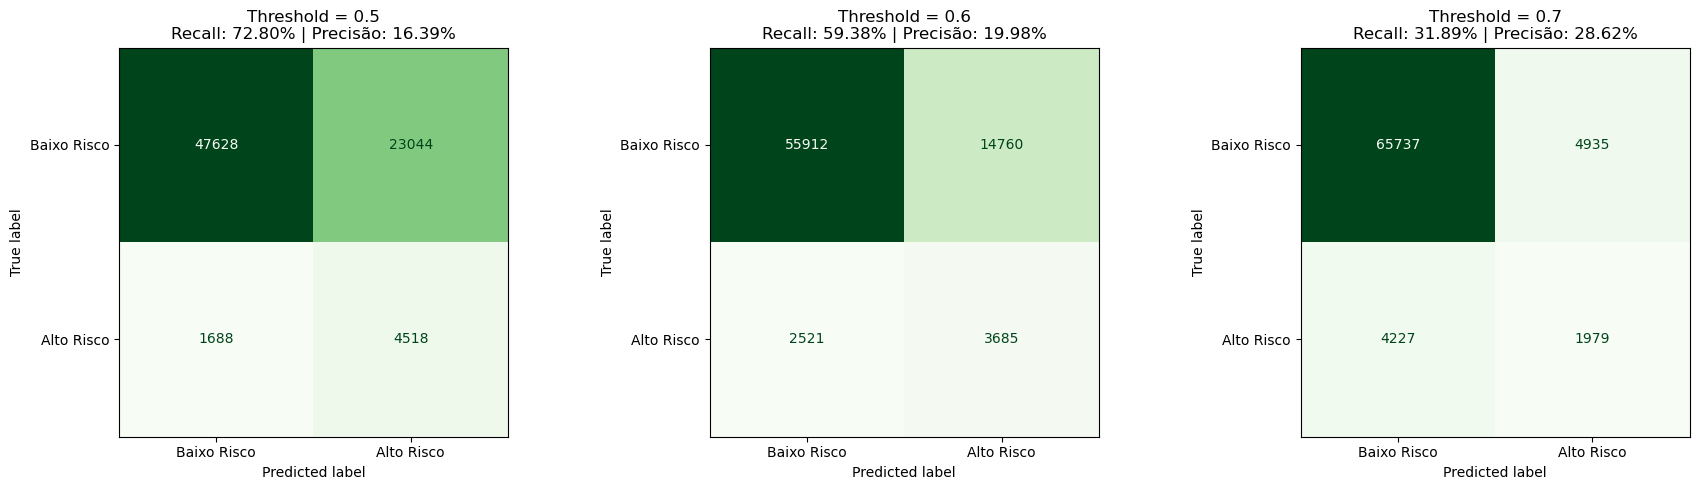

In [25]:
# Teste final do modelo

# Probabilidades previstas no conjunto de teste
y_test_pred_proba = model.predict(X_test_arr).flatten()

# ROC-AUC
final_roc_auc = roc_auc_score(
    y_test_arr,
    y_test_pred_proba
)

print(f'\nROC-AUC final (teste): {final_roc_auc:.4f}')

# Classificação com threshold = 0.5

threshold = 0.5

y_test_pred = (y_test_pred_proba >= threshold).astype(int)

# Matriz de confusão

matrix = confusion_matrix(
    y_test_arr,
    y_test_pred
)

print('\nMatriz de Confusão:')
print(matrix, '\n')

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['Baixo Risco', 'Alto Risco']
)

matrix_display.plot(cmap='Greens')
plt.title(f'Matriz de Confusão - Teste Final (threshold = {threshold})')
plt.show()

tn, fp, fn, tp = matrix.ravel()

print(f'TN (Baixo Risco classificados corretamente): {tn}')
print(f'FP (Baixo Risco classificados como Alto Risco): {fp}')
print(f'FN (Alto Risco classificados como Baixo Risco): {fn}')
print(f'TP (Alto Risco classificados corretamente): {tp}')

# Classification Report

print('\nClassification Report:')
print(
    classification_report(
        y_test_arr,
        y_test_pred,
        target_names=['Baixo Risco', 'Alto Risco'],
        digits=4
    )
)

# Curva Precisão - Recall (escolha do threshold ideal)

precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_test_pred_proba)

fig, ax = plt.subplots()
ax.plot(thresholds, precisions[:-1], label='Precisão', color='#BA2314')
ax.plot(thresholds, recalls[:-1], label='Recall', color='#30823F')
ax.axvline(0.5, color='gray', linestyle='--', label='Threshold atual (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Trade-off Precisão x Recall por Threshold — Alto Risco')
ax.legend()
plt.tight_layout()
plt.show()

# Diferentes thresholds de decisão de negócio

thresholds_compare = [0.5, 0.6, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, t in zip(axes, thresholds_compare):
    y_pred_t = (y_test_pred_proba >= t).astype(int)
    matrix_t = confusion_matrix(y_test_arr, y_pred_t)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix_t,
        display_labels=['Baixo Risco', 'Alto Risco']
    )
    disp.plot(cmap='Greens', ax=ax, colorbar=False)
    
    tn, fp, fn, tp = matrix_t.ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    ax.set_title(f'Threshold = {t}\nRecall: {recall:.2%} | Precisão: {precision:.2%}')

plt.tight_layout()
plt.show()

### Conclusão

O modelo final possui ROC-AUC de aproximadamente 77%, apresentando uma boa capacidade de decisão. Se pegarmos duas pessoas aleatórias, uma da classe positiva (Alto Risco) e outra da classe negativa (Baixo Risco), o modelo possui cerca de 77% de chance de atribuir uma pontuação maior à pessoa da classe positiva. Esse valor de ROC-AUC não depende de nenhum limiar específico, já que a métrica avalia o modelo considerando todos os limiares possíveis. O que depende do limiar escolhido, e consequentemente da regra de negócio, é o resultado prático da classificação: o quanto a empresa está disposta a recusar clientes classificados como Baixo Risco a fim de se proteger de possíveis clientes classificados como Alto Risco.